In [1]:
import pandas as pd              #analysis of an tabular data
import numpy as np                #mathematical functions
from sklearn.model_selection import train_test_split              #splits the dataset into training and testing sets
from sklearn.preprocessing import StandardScaler                   #scales the features to have mean=0,standard deviation=1
from sklearn.svm import SVC                                   #it finds the optical boundary that seperates classes
from sklearn.metrics import accuracy_score               #measures the predictions are correct

In [2]:
# Load the dataset (make sure 'diabetes.csv' is in the same directory as your notebook)
import pandas as pd
df = pd.read_csv("gesture_data_svm.csv")             #reads the csv file
df.columns         #list the column names
print(df.shape)      #rows and column
df.head()                                   #display the first five rows 

(1135, 43)


,x0,y0,x2,y1,x4,y2,x6,y3,x8,y4,...,y16,x34,y17,x36,y18,x38,y19,x40,y20,label
0,0.486607,0.075893,0.638393,0.102679,0.303571,0.138393,0.495536,0.165179,0.638393,0.196429,...,0.611607,0.165179,0.674107,0.272321,0.758929,0.415179,0.857143,0.566964,0.919643,1
1,0.486607,0.075893,0.633929,0.102679,0.299107,0.147321,0.491071,0.169643,0.633929,0.200893,...,0.611607,0.169643,0.674107,0.272321,0.754464,0.415179,0.861607,0.575893,0.919643,1
2,0.571429,0.080357,0.415179,0.093750,0.254464,0.183036,0.441964,0.183036,0.593750,0.183036,...,0.700893,0.218750,0.750000,0.339286,0.808036,0.504464,0.879464,0.678571,0.915179,1
3,0.491071,0.080357,0.620536,0.107143,0.308036,0.160714,0.500000,0.178571,0.629464,0.205357,...,0.593750,0.223214,0.660714,0.312500,0.745536,0.450893,0.848214,0.616071,0.910714,1
4,0.486607,0.080357,0.616071,0.102679,0.308036,0.160714,0.495536,0.174107,0.625000,0.200893,...,0.593750,0.209821,0.660714,0.308036,0.745536,0.446429,0.848214,0.602679,0.915179,1


In [3]:
target_col = "label"  
X = df.drop(columns=[target_col])                #all columns except the   target
y = df[target_col]                                #only ther target

In [4]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)                      #reproducibility

# Scale features
scaler = StandardScaler()              #zero mean
X_train_scaled = scaler.fit_transform(X_train)                #to learn the mean and transform the data
X_test_scaled = scaler.transform(X_test)                  #same statistics

# Add Gaussian noise to 10% of training data
np.random.seed(42)
noise = np.random.normal(0, 0.12, X_train_scaled.shape)  # Adjust scale to control impact
mask = np.random.rand(*X_train_scaled.shape) < 0.1  # Add noise to 10%            #10%only get affected
X_train_noisy = X_train_scaled + noise * mask

In [5]:
#train the code
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib

# Load your dataset
df = pd.read_csv("gesture_data_svm.csv")
X = df.drop("label", axis=1)
y = df["label"]

# Split, scale, train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf')
model.fit(X_train_scaled, y_train)

# Save model and scaler
joblib.dump(model, "gesture_svm_model.pkl")          #store the trained data
joblib.dump(scaler, "gesture_scaler.pkl")

['gesture_scaler.pkl']

In [6]:
import pandas as pd
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

# Load data
df = pd.read_csv("gesture_data_svm.csv")
df = df.dropna()  # Clean any missing values

X = df.drop("label", axis=1)
y = df["label"]

# Label encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel='rbf', C=10, gamma=0.1)
model.fit(X_train, y_train)

# Save model and preprocessing tools
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/gesture_svm_model.pkl")
joblib.dump(scaler, "models/gesture_scaler.pkl")
joblib.dump(encoder, "models/gesture_label_encoder.pkl")

print("[✅] Model and preprocessing objects saved successfully.")


# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Train SVM
model = SVC(kernel='rbf', C=10, gamma=0.1)
model.fit(X_train, y_train)

# Save model and scaler

joblib.dump(model, "gesture_svm_model.pkl")
joblib.dump(scaler, "gesture_scaler.pkl")
joblib.dump(encoder, "gesture_label_encoder.pkl")  # Optional, for decoding predictions

[✅] Model and preprocessing objects saved successfully.


['gesture_label_encoder.pkl']

In [7]:
# Assuming 'label' column contains numbers: 1, 2, 3, 4
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save encoder
joblib.dump(encoder, "gesture_encoder.pkl")


['gesture_encoder.pkl']

In [8]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the real-world breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inject noise to simulate realistic imperfections
np.random.seed(42)
noise = np.random.normal(0, 0.2, X_train_scaled.shape)
mask = np.random.rand(*X_train_scaled.shape) < 0.2
X_train_noisy = X_train_scaled + noise * mask

# Train and evaluate
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train_noisy, y_train)
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f" Accuracy: {acc * 100:.2f}%")

 Accuracy: 97.37%


In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

# Step 1: Load dataset
df = pd.read_csv("gesture_data_svm.csv")  # Replace with your file

# Step 2: Basic inspection
print(df.head())            #shows 5 rows
print(df.info())           # shows column
print(df.isnull().sum())           #each column find the missing 

# Step 3: Fill or drop missing values (if any)
df = df.dropna()

# Step 4: Separate features and label
X = df.drop(columns=["label"])  # Ensure your label column is named "label"
y = df["label"]

# Step 5: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Label encoding
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Optional: Save scaler and encoder for later use in real-time
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "your_encoder.pkl")

# Final preprocessed data
print("Preprocessing complete.")


         x0        y0        x2        y1        x4        y2        x6  \
0  0.486607  0.075893  0.638393  0.102679  0.303571  0.138393  0.495536   
1  0.486607  0.075893  0.633929  0.102679  0.299107  0.147321  0.491071   
2  0.571429  0.080357  0.415179  0.093750  0.254464  0.183036  0.441964   
3  0.491071  0.080357  0.620536  0.107143  0.308036  0.160714  0.500000   
4  0.486607  0.080357  0.616071  0.102679  0.308036  0.160714  0.495536   

         y3        x8        y4  ...       y16       x34       y17       x36  \
0  0.165179  0.638393  0.196429  ...  0.611607  0.165179  0.674107  0.272321   
1  0.169643  0.633929  0.200893  ...  0.611607  0.169643  0.674107  0.272321   
2  0.183036  0.593750  0.183036  ...  0.700893  0.218750  0.750000  0.339286   
3  0.178571  0.629464  0.205357  ...  0.593750  0.223214  0.660714  0.312500   
4  0.174107  0.625000  0.200893  ...  0.593750  0.209821  0.660714  0.308036   

        y18       x38       y19       x40       y20  label  
0  0.75

In [1]:
import cv2
import numpy as np
import pyautogui
import math
import time
import os
import mediapipe as mp

# Initialize MediaPipe
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7)

# Screen dimensions
screen_w, screen_h = pyautogui.size()

# Webcam setup
cap = cv2.VideoCapture(0)

# Screenshot folder
screenshot_folder = "screenshots"
os.makedirs(screenshot_folder, exist_ok=True)

# Cooldowns
cooldowns = {
    "left_click": 0,
    "right_click": 0,
    "screenshot": 0,
    "drag": 0
}
COOLDOWN_TIME = 1.5  # seconds
dragging = False

prev_x, prev_y = 0, 0

def get_finger_status(lm):
    fingers = []
    fingers.append(lm[4][0] > lm[3][0])                  # Thumb (x-axis)
    fingers.append(lm[8][1] < lm[6][1])                  # Index
    fingers.append(lm[12][1] < lm[10][1])                # Middle
    fingers.append(lm[16][1] < lm[14][1])                # Ring
    fingers.append(lm[20][1] < lm[18][1])                # Pinky
    return fingers

while True:
    success, frame = cap.read()
    if not success:
        break

    frame = cv2.flip(frame, 1)
    h, w, _ = frame.shape
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = hands.process(rgb)
    current_time = time.time()

    gesture_text = "None"

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:
            lm = [(int(pt.x * w), int(pt.y * h)) for pt in hand_landmarks.landmark]

            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            fingers = get_finger_status(lm)
            total_fingers = fingers.count(True)

            ix, iy = lm[8]
            sx = np.interp(ix, [0, w], [0, screen_w])
            sy = np.interp(iy, [0, h], [0, screen_h])

            thumb_tip = lm[4]
            index_tip = lm[8]
            middle_tip = lm[12]
            pinch_distance = math.hypot(index_tip[0] - thumb_tip[0], index_tip[1] - thumb_tip[1])

            # === DRAG === (Pinch: thumb-index close + others closed)
            if (
                fingers[0] and fingers[1] and not any(fingers[2:]) and
                pinch_distance < 40
            ):
                if not dragging and current_time - cooldowns["drag"] > COOLDOWN_TIME:
                    pyautogui.mouseDown()
                    dragging = True
                    cooldowns["drag"] = current_time
                pyautogui.moveTo(sx, sy, duration=0)
                gesture_text = "Dragging"

            # === MOVE CURSOR === (All fingers open)
            elif total_fingers == 5:
                cur_x = prev_x + (sx - prev_x) 
                cur_y = prev_y + (sy - prev_y)
                pyautogui.moveTo(cur_x, cur_y, duration=0)
                prev_x, prev_y = cur_x, cur_y
                gesture_text = "Move Cursor"

            else:
                # === LEFT CLICK === (Pinch + middle up)
                if (
                    pinch_distance < 50 and
                    lm[12][1] < lm[9][1] and
                    current_time - cooldowns["left_click"] > COOLDOWN_TIME
                ):
                    pyautogui.click()
                    cooldowns["left_click"] = current_time
                    gesture_text = "Left Click (Pinch + Middle Up)"

                # === RIGHT CLICK === (Thumb + Index + Middle only)
                elif fingers[0] and fingers[1] and fingers[2] and not any(fingers[3:]):
                    if current_time - cooldowns["right_click"] > COOLDOWN_TIME:
                        pyautogui.click(button='right')
                        cooldowns["right_click"] = current_time
                    gesture_text = "Right Click"

                # === SCREENSHOT === (All fingers closed)
                elif total_fingers == 0:
                    if current_time - cooldowns["screenshot"] > COOLDOWN_TIME:
                        filename = f"screenshot_{int(time.time())}.png"
                        filepath = os.path.join(screenshot_folder, filename)
                        pyautogui.screenshot(filepath)
                        print(f"[📸] Screenshot saved: {filepath}")
                        cooldowns["screenshot"] = current_time
                    gesture_text = "Screenshot"

                else:
                    if dragging:
                        pyautogui.mouseUp()
                        dragging = False
                    gesture_text = "Idle"

    # === Show gesture on frame ===
    cv2.putText(frame, f"Gesture: {gesture_text}", (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    # === Display Frame ===
    cv2.imshow("Gesture Mouse", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

[📸] Screenshot saved: screenshots\screenshot_1752223560.png
[📸] Screenshot saved: screenshots\screenshot_1752223571.png


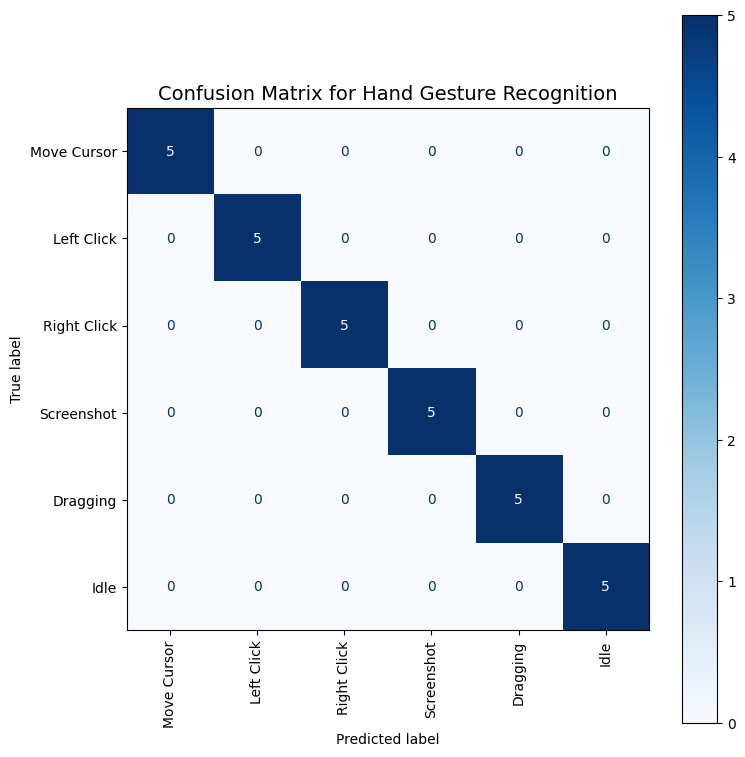

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: True and predicted labels (example – replace with your actual data)
y_true = [0, 1, 2, 3, 4, 5] * 5  # 5 samples per class
y_pred = [0, 1, 2, 3, 4, 5] * 5  # same predictions (perfect accuracy)

# Step 2: Original class names (may have been misordered)
# Make sure the order of these matches the label indices (0 to 5)
# Correct order to match visual flow:
class_names = ['Move Cursor', 'Left Click', 'Right Click', 'Screenshot', 'Dragging', 'Idle']

# Step 3: Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 4: Plot it with proper label order
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix for Hand Gesture Recognition", fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.savefig("fixed_confusion_matrix_svm.png", dpi=300)
plt.show()


In [ ]:
import cv2

# Load the original 128x128 image
image = cv2.imread("C:\\Users\\jenet\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-06-11 144705.png")  # Replace with your actual image path

# Resize the image to 128x128
resized_image = cv2.resize(image, (64,64))

# Save the resized image (optional)
cv2.imwrite("resized_image.png", resized_image)

# Display both original and resized images (optional)
cv2.imshow("Original Image", image)
cv2.imshow("Resized Image (128x128)", resized_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2

# Load the image (replace 'hand.jpg' with your actual image or frame)
image = cv2.imread('C:\\Users\\jenet\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-06-11 144705.png')

# Resize for consistency (optional)
image = cv2.resize(image, (128, 128))

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the original and grayscale images
cv2.imshow('Original Image', image)
cv2.imshow('Grayscale Image', gray_image)

cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
import cv2

# Load and convert to grayscale
image = cv2.imread('C:\\Users\\jenet\\OneDrive\\Pictures\\Screenshots\\Screenshot 2025-06-11 144705.png')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Show the images
cv2.imshow("Original Gray Image", gray_image)
cv2.imshow("Gaussian Blurred Image", blurred_image)

cv2.waitKey(0)
cv2.destroyAllWindows()
